# 📊 Lab Work - 3.1


# 🔹 Q1: Data Cleaning & Encoding

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Create dataset
df = pd.DataFrame({
    'Age': [25, 30, 22, 40, 35],
    'Salary': [50000, np.nan, 45000, np.nan, 70000],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female'],
    'Education': ['Graduate', 'Postgraduate', 'High School', 'Graduate', 'Postgraduate']
})

df

,Age,Salary,Gender,Education
0,25,50000.0,Male,Graduate
1,30,NaN,Female,Postgraduate
2,22,45000.0,Female,High School
3,40,NaN,Male,Graduate
4,35,70000.0,Female,Postgraduate


In [3]:
# Handle missing values (median)
df['Salary'].fillna(df['Salary'].median(), inplace=True)

df

C:\Users\Dell\AppData\Local\Temp\ipykernel_24960\1183554859.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(), inplace=True)


,Age,Salary,Gender,Education
0,25,50000.0,Male,Graduate
1,30,50000.0,Female,Postgraduate
2,22,45000.0,Female,High School
3,40,50000.0,Male,Graduate
4,35,70000.0,Female,Postgraduate


In [4]:
# One-Hot Encoding (Gender)
gender_encoded = pd.get_dummies(df['Gender'], prefix='Gender')

# Ordinal Encoding (Education)
edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
df['Education'] = df['Education'].map(edu_map)

# Merge
df_final = pd.concat([df.drop('Gender', axis=1), gender_encoded], axis=1)

df_final

,Age,Salary,Education,Gender_Female,Gender_Male
0,25,50000.0,2,False,True
1,30,50000.0,3,True,False
2,22,45000.0,1,True,False
3,40,50000.0,2,False,True
4,35,70000.0,3,True,False


# 🔹 Q2: Date Processing & Visualization

In [5]:
# Create dataset
df2 = pd.DataFrame({
    'OrderID': [1,2,3,4,5],
    'OrderDate': ['2023-01-01','2023-02-15','2023-03-10','2023-03-25','2023-04-05'],
    'DeliveryDate': ['2023-01-05','2023-02-20','2023-03-15','2023-03-30','2023-04-10']
})

df2

,OrderID,OrderDate,DeliveryDate
0,1,2023-01-01,2023-01-05
1,2,2023-02-15,2023-02-20
2,3,2023-03-10,2023-03-15
3,4,2023-03-25,2023-03-30
4,5,2023-04-05,2023-04-10


In [6]:
# Convert to datetime
df2['OrderDate'] = pd.to_datetime(df2['OrderDate'])
df2['DeliveryDate'] = pd.to_datetime(df2['DeliveryDate'])

# Extract features
df2['Year'] = df2['OrderDate'].dt.year
df2['Month'] = df2['OrderDate'].dt.month
df2['Day'] = df2['OrderDate'].dt.day

# Delivery duration
df2['Delivery_Days'] = (df2['DeliveryDate'] - df2['OrderDate']).dt.days

# Weekday vs Weekend
df2['Weekend'] = df2['OrderDate'].dt.weekday >= 5

df2

,OrderID,OrderDate,DeliveryDate,Year,Month,Day,Delivery_Days,Weekend
0,1,2023-01-01,2023-01-05,2023,1,1,4,True
1,2,2023-02-15,2023-02-20,2023,2,15,5,False
2,3,2023-03-10,2023-03-15,2023,3,10,5,False
3,4,2023-03-25,2023-03-30,2023,3,25,5,True
4,5,2023-04-05,2023-04-10,2023,4,5,5,False


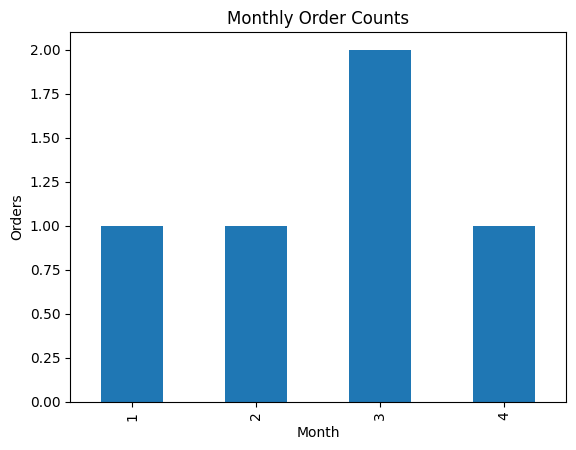

In [7]:
import matplotlib.pyplot as plt

# Monthly orders
monthly_counts = df2['Month'].value_counts().sort_index()

monthly_counts.plot(kind='bar')
plt.title('Monthly Order Counts')
plt.xlabel('Month')
plt.ylabel('Orders')
plt.show()

# 🔹 Q3: Missing Values Analysis

In [8]:
# Create dataset with missing values
df3 = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [np.nan, 2, 3, 4],
    'C': [1, np.nan, np.nan, 4]
})

df3

,A,B,C
0,1.0,NaN,1.0
1,2.0,2.0,NaN
2,NaN,3.0,NaN
3,4.0,4.0,4.0


In [9]:
# Count rows with at least one missing value
missing_rows = df3.isnull().any(axis=1).sum()
print('Rows with missing values:', missing_rows)

Rows with missing values: 3


In [10]:
# Drop rows with NaN
df3_clean = df3.dropna()

print('Before:', df3.shape)
print('After:', df3_clean.shape)

df3_clean

Before: (4, 3)
After: (1, 3)


,A,B,C
3,4.0,4.0,4.0
